In [1]:
import mpmath as mp
mp.mp.dps = 50 #50-decimal precision

In [2]:
val = []

### Deriving $\sin(10^\circ)$ using a Cubic Equation

We start from the triple-angle identity:

$$
\sin(3x) = 3\sin(x) - 4\sin^3(x)
$$

Substituting $x = 10^\circ$:

$$
\sin(30^\circ) = 3\sin(10^\circ) - 4\sin^3(10^\circ)
$$

Since:

$$
\sin(30^\circ) = \frac{1}{2}
$$

Let:

$$
y = \sin(10^\circ)
$$

We obtain:

$$
3y - 4y^3 = \frac{1}{2}
$$

Rearranging:

$$
8y^3 - 6y + 1 = 0
$$

This reduces the problem to solving a cubic equation.

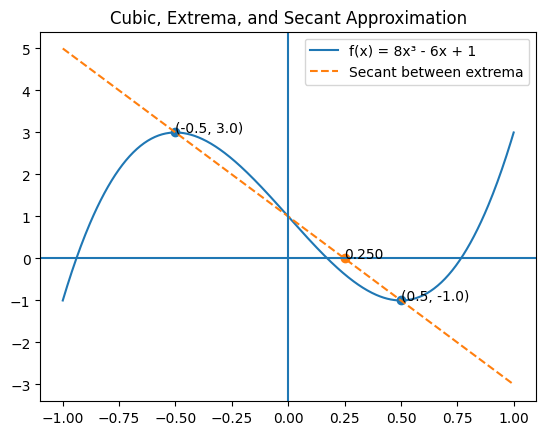

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Function
def f(x):
    return 8*x**3 - 6*x + 1

# Derivative for extrema
def f_prime(x):
    return 24*x**2 - 6

# Generate curve
x = np.linspace(-1, 1, 500)
y = f(x)

# Solve f'(x) = 0 → extrema
x_extrema = np.array([0.5, -0.5])
y_extrema = f(x_extrema)

# Secant line between extrema
x1, x2 = x_extrema
y1, y2 = y_extrema

# Line equation: y = m*x + c
m = (y2 - y1) / (x2 - x1)
c = y1 - m*x1

# Generate secant line
x_secant = np.linspace(-1, 1, 500)
y_secant = m * x_secant + c

# Find where secant crosses x-axis → y = 0
x_intercept = -c / m

# Plot everything
plt.figure()

# Cubic
plt.plot(x, y, label="f(x) = 8x³ - 6x + 1")

# Extrema points
plt.scatter(x_extrema, y_extrema)
for i in range(2):
    plt.text(x_extrema[i], y_extrema[i], f"({x_extrema[i]}, {y_extrema[i]})")

# Secant line
plt.plot(x_secant, y_secant, linestyle='--', label="Secant between extrema")

# Secant x-intercept
plt.scatter([x_intercept], [0])
plt.text(x_intercept, 0, f"{x_intercept:.3f}")

# Axes
plt.axhline(0)
plt.axvline(0)

plt.title("Cubic, Extrema, and Secant Approximation")
plt.legend()

plt.show()

### Initial Approximation via Geometric Insight

From the graph of the cubic:

$$
f(x) = 8x^3 - 6x + 1
$$

we observe that the extrema occur at:

$$
f'(x) = 24x^2 - 6 = 0 \Rightarrow x = \pm 0.5
$$

Drawing a secant line between these extrema and finding its intersection with the x-axis gives an approximate root:

$$
x_0 \approx 0.25
$$

This serves as an initial estimate for $\sin(10^\circ)$.

---

### Iterative Refinement using Linear Approximation

Assume the true root is:

$$
x + a
$$

where $a$ is a small correction.

Substitute into the cubic:

$$
8(x+a)^3 - 6(x+a) + 1 = 0
$$

Using first-order approximation:

$$
(x+a)^3 \approx x^3 + 3x^2 a
$$

we get:

$$
8(x^3 + 3x^2 a) - 6(x + a) + 1 = 0
$$

Expanding:

$$
8x^3 + 24x^2 a - 6x - 6a + 1 = 0
$$

Rearranging:

$$
(8x^3 - 6x + 1) + (24x^2 - 6)a = 0
$$

Solving for $a$:

$$
a = \frac{8x^3 - 6x + 1}{6 - 24x^2}
$$

This gives an iterative update:

$$
x_{n+1} = x_n + a
$$

---

### Connection to Newton-Raphson Method

The update rule:

$$
x_{n+1} = x_n + \frac{8x^3 - 6x + 1}{6 - 24x^2}
$$

is equivalent to the Newton-Raphson method applied to:

$$
f(x) = 8x^3 - 6x + 1
$$

$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$

This explains the rapid (quadratic) convergence observed in practice.

In [4]:
num_epochs = 10
x = mp.mpf(0.25)
a = mp.mpf(0)
for epoch in range(num_epochs):
    val.append(x)
    a = (8*x**3-6*x+1)/(6-24*x**2)
    x += a

In [5]:
print(x, mp.sin(mp.radians(10)))

0.17364817766693034885171662676931479600037567718407 0.17364817766693034885171662676931479600037567718407


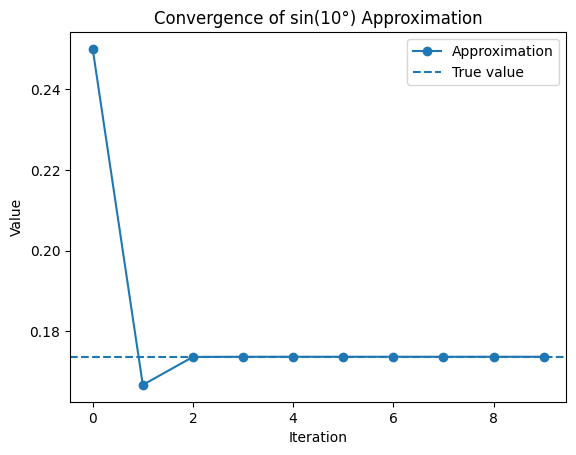

In [11]:
import matplotlib.pyplot as plt
import mpmath as mp

true_val = float(mp.sin(mp.radians(10)))
val_float = [float(v) for v in val]

plt.plot(val_float, marker='o', label='Approximation')
plt.axhline(true_val, linestyle='--', label='True value')

plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Convergence of sin(10°) Approximation')
plt.legend()

plt.show()

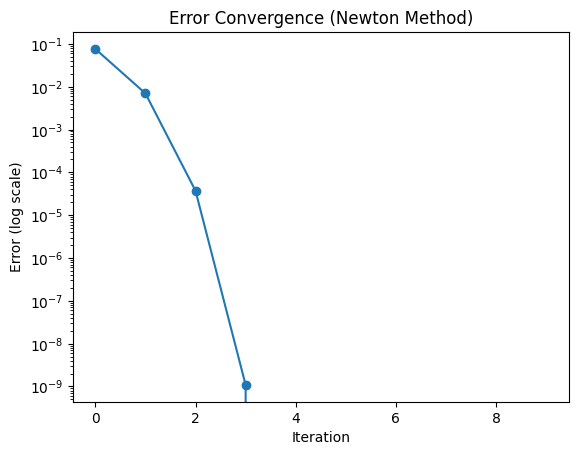

In [12]:
errors = [abs(v - true_val) for v in val_float]

plt.plot(errors, marker='o')
plt.yscale('log')  # IMPORTANT

plt.xlabel('Iteration')
plt.ylabel('Error (log scale)')
plt.title('Error Convergence (Newton Method)')

plt.show()